# 04 — Model Training

Train all four models on all three horizons.  
Models are saved to `models/` for evaluation and live inference.

| Model | Input | Notes |
|---|---|---|
| Logistic Regression | flat (n, features) | StandardScaler applied |
| LightGBM | flat (n, features) | early stopping on val set |
| LSTM | windowed (n, window, features) | MinMaxScaler, early stopping |
| TFT | feature DataFrame | pytorch-forecasting TimeSeriesDataSet |

**Split:** 70% train / 15% val / 15% test — strict chronological order.

In [1]:
import sys
from pathlib import Path

# Resolve project root robustly (works in VS Code Jupyter where CWD = workspace root)
try:
    ROOT = Path(__vsc_ipynb_file__).parent.parent.resolve()
except NameError:
    ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features import build_features, get_feature_cols, create_windows
from src.models import LogisticRegressionModel, LightGBMModel, LSTMModel, TFTModel
from src.evaluate import chronological_split, split_windows

PROCESSED = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)

WINDOW_SIZE = 48   # lookback window for LSTM / TFT (candles)
HORIZONS = ['5m', '30m', '1h']

## 1. Load & Feature-Engineer Data for All Horizons

In [2]:
feat_frames = {}
for label in HORIZONS:
    raw = pd.read_csv(PROCESSED / f'btc_{label}.csv',
                      index_col='timestamp', parse_dates=True)
    print(f"\n=== {label} ===")
    feat_frames[label] = build_features(raw)


=== 5m ===
[features] Building features  (rows before: 758,593) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 758,559,  features: 15)

=== 30m ===
[features] Building features  (rows before: 126,433) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 126,399,  features: 15)

=== 1h ===
[features] Building features  (rows before: 63,217) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 63,183,  features: 15)


## 2. Prepare Splits

In [3]:
splits = {}  # splits[horizon] = (train_df, val_df, test_df)

for label, df in feat_frames.items():
    print(f"\n--- {label} ---")
    train, val, test = chronological_split(df)
    splits[label] = (train, val, test)


--- 5m ---
[eval] Split → train 530,991  val 113,784  test 113,784  (2019-01-01 / 2024-01-18 / 2025-02-16)

--- 30m ---
[eval] Split → train 88,479  val 18,960  test 18,960  (2019-01-01 / 2024-01-19 / 2025-02-17)

--- 1h ---
[eval] Split → train 44,228  val 9,477  test 9,478  (2019-01-02 / 2024-01-19 / 2025-02-17)


In [4]:
# Also prepare flat arrays (LR / LGBM) and windowed arrays (LSTM)
flat_splits  = {}  # flat_splits[horizon]    = ((Xtr,ytr), (Xvl,yvl), (Xte,yte))
win_splits   = {}  # win_splits[horizon]     = ((Xtr,ytr), (Xvl,yvl), (Xte,yte))

for label, df in feat_frames.items():
    feat_cols = get_feature_cols(df)
    X_flat = df[feat_cols].values.astype(np.float32)
    y_flat = df['target'].values.astype(np.float32)
    flat_splits[label] = split_windows(X_flat, y_flat)

    print()
    X_win, y_win = create_windows(df, window_size=WINDOW_SIZE)
    win_splits[label] = split_windows(X_win, y_win)

[eval]   train: X=(530991, 15)  y=(530991,)  pos_rate=0.500
[eval]   val  : X=(113784, 15)  y=(113784,)  pos_rate=0.502
[eval]   test : X=(113784, 15)  y=(113784,)  pos_rate=0.498

[features] Windows: X=(758512, 48, 15), y=(758512,)  (window_size=48, features=15)
[eval]   train: X=(530958, 48, 15)  y=(530958,)  pos_rate=0.500
[eval]   val  : X=(113777, 48, 15)  y=(113777,)  pos_rate=0.502
[eval]   test : X=(113777, 48, 15)  y=(113777,)  pos_rate=0.498
[eval]   train: X=(88479, 15)  y=(88479,)  pos_rate=0.506
[eval]   val  : X=(18960, 15)  y=(18960,)  pos_rate=0.507
[eval]   test : X=(18960, 15)  y=(18960,)  pos_rate=0.507

[features] Windows: X=(126352, 48, 15), y=(126352,)  (window_size=48, features=15)
[eval]   train: X=(88446, 48, 15)  y=(88446,)  pos_rate=0.506
[eval]   val  : X=(18953, 48, 15)  y=(18953,)  pos_rate=0.507
[eval]   test : X=(18953, 48, 15)  y=(18953,)  pos_rate=0.507
[eval]   train: X=(44228, 15)  y=(44228,)  pos_rate=0.508
[eval]   val  : X=(9477, 15)  y=(9477,)  p

## 3. Logistic Regression

In [5]:
lr_models = {}

for label in HORIZONS:
    print(f"\n=== LR — {label} ===")
    (Xtr, ytr), (Xvl, yvl), _ = flat_splits[label]

    model = LogisticRegressionModel()
    model.train(Xtr, ytr, Xvl, yvl)
    model.save(MODEL_DIR / f'lr_{label}.pkl')
    lr_models[label] = model


=== LR — 5m ===
[LR] Fitting …
[LR] Train accuracy: 0.5359
[LR] Val   accuracy: 0.5152
[LR] Saved → /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lr_5m.pkl

=== LR — 30m ===
[LR] Fitting …
[LR] Train accuracy: 0.5426
[LR] Val   accuracy: 0.5324
[LR] Saved → /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lr_30m.pkl

=== LR — 1h ===
[LR] Fitting …
[LR] Train accuracy: 0.5449
[LR] Val   accuracy: 0.5237
[LR] Saved → /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lr_1h.pkl


## 4. LightGBM

In [6]:
lgbm_models = {}

for label in HORIZONS:
    print(f"\n=== LGBM — {label} ===")
    (Xtr, ytr), (Xvl, yvl), _ = flat_splits[label]

    model = LightGBMModel()
    model.train(Xtr, ytr, Xvl, yvl)
    model.save(MODEL_DIR / f'lgbm_{label}.pkl')
    lgbm_models[label] = model


=== LGBM — 5m ===
[LGBM] Training …
[LightGBM] [Info] Number of positive: 265348, number of negative: 265643
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002304 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3346
[LightGBM] [Info] Number of data points in the train set: 530991, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499722 -> initscore=-0.001111
[LightGBM] [Info] Start training from score -0.001111
Training until validation scores don't improve for 30 rounds
[50]	valid_0's binary_logloss: 0.692329
Early stopping, best iteration is:
[22]	valid_0's binary_logloss: 0.692157
[LGBM] Best iteration: 22
[LGBM] Saved → /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lgbm_5m.pkl

=== LGBM — 30m ===
[LGBM] Training …
[LightGBM] [Info] Number of positive: 44792, number of neg

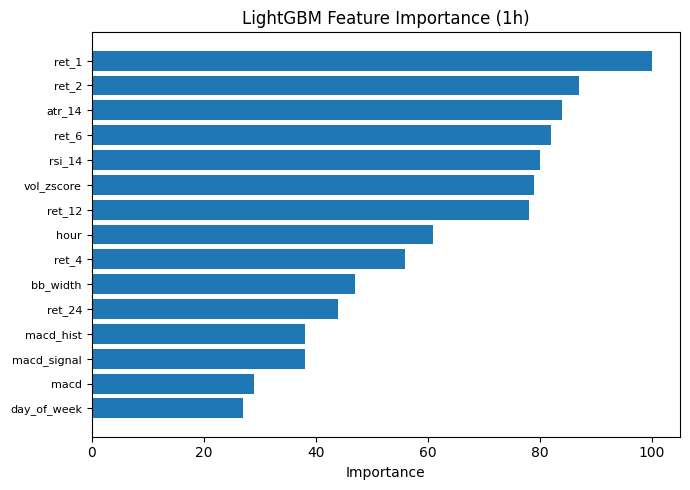

In [7]:
# Feature importance for LightGBM (1h as example)
from src.evaluate import plot_feature_importance

feat_cols_1h = get_feature_cols(feat_frames['1h'])
fig, ax = plt.subplots(figsize=(7, 5))
plot_feature_importance(
    lgbm_models['1h'].feature_importances_,
    feat_cols_1h,
    top_n=len(feat_cols_1h),
    title='LightGBM Feature Importance (1h)',
    ax=ax,
)
plt.tight_layout()
plt.show()

## 5. LSTM

In [8]:
lstm_models = {}

for label in HORIZONS:
    print(f"\n=== LSTM — {label} ===")
    (Xtr, ytr), (Xvl, yvl), _ = win_splits[label]

    _, window, n_features = Xtr.shape
    model = LSTMModel(window_size=window, n_features=n_features)
    history = model.train(Xtr, ytr, Xvl, yvl)
    model.save(MODEL_DIR / f'lstm_{label}')
    lstm_models[label] = (model, history)


=== LSTM — 5m ===


2026-03-19 03:56:23.845762: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-19 03:56:23.846155: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-19 03:56:23.846217: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-19 03:56:23.846313: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-19 03:56:23.846379: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input

[LSTM] Training  epochs=50  batch=64 …
Epoch 1/50


2026-03-19 03:56:26.423564: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


8297/8297 ━━━━━━━━━━━━━━━━━━━━ 136s 16ms/step - accuracy: 0.5169 - loss: 0.6921 - val_accuracy: 0.5146 - val_loss: 0.6927
Epoch 2/50
8297/8297 ━━━━━━━━━━━━━━━━━━━━ 128s 15ms/step - accuracy: 0.5341 - loss: 0.6898 - val_accuracy: 0.5124 - val_loss: 0.6932
Epoch 3/50
8297/8297 ━━━━━━━━━━━━━━━━━━━━ 128s 15ms/step - accuracy: 0.5348 - loss: 0.6896 - val_accuracy: 0.5130 - val_loss: 0.6934
Epoch 4/50
8297/8297 ━━━━━━━━━━━━━━━━━━━━ 127s 15ms/step - accuracy: 0.5359 - loss: 0.6894 - val_accuracy: 0.5118 - val_loss: 0.6938
Epoch 5/50
8297/8297 ━━━━━━━━━━━━━━━━━━━━ 128s 15ms/step - accuracy: 0.5358 - loss: 0.6893 - val_accuracy: 0.5138 - val_loss: 0.6930
Epoch 6/50
8297/8297 ━━━━━━━━━━━━━━━━━━━━ 127s 15ms/step - accuracy: 0.5363 - loss: 0.6891 - val_accuracy: 0.5133 - val_loss: 0.6940
Epoch 7/50
8297/8297 ━━━━━━━━━━━━━━━━━━━━ 128s 15ms/step - accuracy: 0.5369 - loss: 0.6890 - val_accuracy: 0.5116 - val_loss: 0.6942
Epoch 8/50
8297/8297 ━━━━━━━━━━━━━━━━━━━━ 127s 15ms/step - accuracy: 0.5371 - lo

/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[LSTM] Training  epochs=50  batch=64 …
Epoch 1/50
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.5030 - loss: 0.6937 - val_accuracy: 0.4930 - val_loss: 0.6939
Epoch 2/50
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.5063 - loss: 0.6932 - val_accuracy: 0.5057 - val_loss: 0.6931
Epoch 3/50
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.5115 - loss: 0.6928 - val_accuracy: 0.5113 - val_loss: 0.6924
Epoch 4/50
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.5199 - loss: 0.6920 - val_accuracy: 0.5195 - val_loss: 0.6918
Epoch 5/50
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.5294 - loss: 0.6909 - val_accuracy: 0.5361 - val_loss: 0.6904
Epoch 6/50
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.5367 - loss: 0.6900 - val_accuracy: 0.5331 - val_loss: 0.6905
Epoch 7/50
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.5395 - loss: 0.6895 - val_accuracy: 0.5339 - val_loss: 0.6903
Epoch 8/50
1382/1382 ━━━━━━━━━━━━━━━━

/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


691/691 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5032 - loss: 0.6937 - val_accuracy: 0.5108 - val_loss: 0.6932
Epoch 2/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5066 - loss: 0.6932 - val_accuracy: 0.5029 - val_loss: 0.6931
Epoch 3/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5080 - loss: 0.6929 - val_accuracy: 0.4983 - val_loss: 0.6934
Epoch 4/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5113 - loss: 0.6928 - val_accuracy: 0.4963 - val_loss: 0.6932
Epoch 5/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5114 - loss: 0.6927 - val_accuracy: 0.5023 - val_loss: 0.6931
Epoch 6/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5138 - loss: 0.6925 - val_accuracy: 0.5121 - val_loss: 0.6928
Epoch 7/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5182 - loss: 0.6922 - val_accuracy: 0.5143 - val_loss: 0.6927
Epoch 8/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5230 - loss: 0.6920 - val_accurac

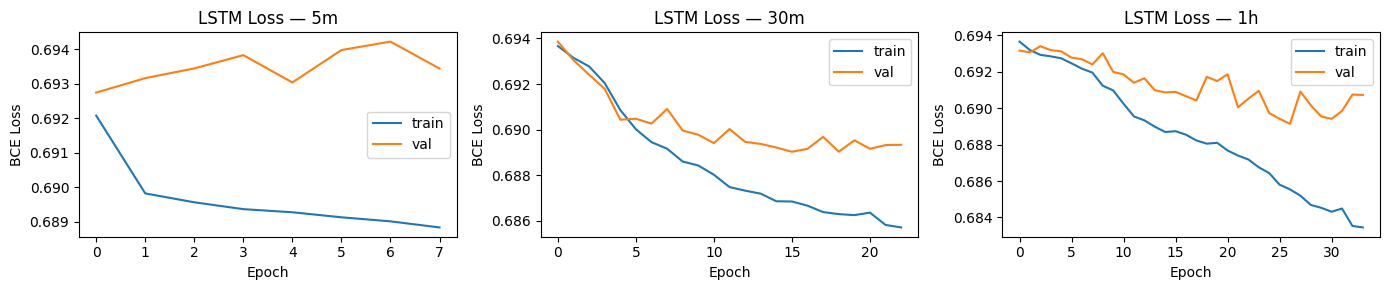

In [9]:
# Training curves for LSTM
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

for ax, label in zip(axes, HORIZONS):
    _, hist = lstm_models[label]
    ax.plot(hist.history['loss'],     label='train')
    ax.plot(hist.history['val_loss'], label='val')
    ax.set_title(f'LSTM Loss — {label}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Temporal Fusion Transformer

> **Note:** TFT training is slow (~10-30 min per horizon).  
> Set `TRAIN_TFT = False` to skip and load from a checkpoint.

In [12]:
TRAIN_TFT = False
tft_models = {}

if TRAIN_TFT:
    for label in HORIZONS:
        print(f"\n=== TFT — {label} ===")
        train_df, val_df, _ = splits[label]
        feat_cols = get_feature_cols(feat_frames[label])

        model = TFTModel(
            window_size=WINDOW_SIZE,
            feature_cols=feat_cols,
        )
        model.train(train_df, val_df)
        model.save(MODEL_DIR / f'tft_{label}')
        tft_models[label] = model
else:
    # No checkpoints available — TFT skipped
    print("[TFT] Skipped (TRAIN_TFT=False and no saved checkpoints).")

[TFT] Skipped (TRAIN_TFT=False and no saved checkpoints).


## Summary

All models trained and saved to `models/`:
```
models/
  lr_5m.pkl      lr_30m.pkl      lr_1h.pkl
  lgbm_5m.pkl    lgbm_30m.pkl    lgbm_1h.pkl
  lstm_5m.keras  lstm_30m.keras  lstm_1h.keras
  tft_5m.pt      tft_30m.pt      tft_1h.pt
```

Proceed to `05_evaluation.ipynb` for test-set metrics and comparison.